# **Project 4: Feature Extraction and Price Prediction for Mobile Phones**

**Import Libraries**

In [ ]:
#data handle
import pandas as pd
#numerical operations
import numpy as np
#graphs
import matplotlib.pyplot as plt
#professional visualization
import seaborn as sns

# Model Building
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Load The Data**

In [ ]:
# Load Data
df = pd.read_excel('Processed_Flipdata.xlsx')

**Show All DataFrame Columns And Rows**

In [ ]:
# Show All data from DataSet
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999
5,5,Infinix HOT 30i,Glacier Blue,128,8,5000,50MP,5MP,1,16.76,G37,8999
6,6,Infinix HOT 30i,Mirror Black,128,8,5000,50MP,5MP,1,16.76,G37,8999
7,7,Infinix HOT 30i,Diamond White,128,8,5000,50MP,5MP,1,16.76,G37,8999
8,8,Infinix HOT 30i,Diamond White,64,4,5000,50MP,5MP,1,16.76,G37,7999
9,9,Infinix HOT 30i,Mirror Black,64,4,5000,50MP,5MP,1,16.76,G37,7999


# **Data Exploration**

**Show Top Five Rows**

In [ ]:
df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999


**Show Bottom Five Rows**

In [ ]:
df.tail()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
536,637,SAMSUNG Galaxy S23 5G,Cream,256,8,3900,50MP,12MP,0,15.49,Qualcomm Snapdragon 8 Gen 2,79999
537,638,LAVA Z21,Cyan,32,2,3100,5MP,2MP,0,12.70,Octa Core,5998
538,639,Tecno Spark 8T,Turquoise Cyan,64,4,5000,50MP,8MP,0,16.76,MediaTek Helio G35,9990
539,641,SAMSUNG Galaxy A54 5G,Awesome Lime,128,8,5000,50MP,32MP,0,16.26,"Exynos 1380, Octa Core",38999
540,642,OPPO A77,Sky Blue,128,4,5000,50MP,8MP,0,16.66,Mediatek Helio G35,15999


**Show Random Five rows**

In [ ]:
df.sample(5)

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
109,109,Infinix Note 12 Pro 5G,Force Black,128,8,5000,108MP,16MP,0,17.02,Mediatek Dimensity 810 5G,15999
243,243,redmi max,M3),16,2,5000,13MP,5MP,0,15.46,Octa Core,4999
470,536,realme Narzo 50A Prime,Flash Black,128,4,5000,50MP,8MP,0,16.76,MediaTek Helio G88,12599
414,446,Tecno Spark 9,Sky Mirror,64,3,5000,13MP,8MP,0,16.76,MediaTek Helio G37,8990
375,390,Infinix Smart 6,Polar Black,64,2,5000,8MP,5MP,0,16.76,Mediatek Helio A22,6999


**Show All Information of Data**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 50.8+ KB


**Show all Columns And Rows in Number format**

In [8]:
df.shape

(541, 12)

**Show All Columns**

In [9]:
df.columns

Index(['Unnamed: 0', 'Model', 'Colour', 'Memory', 'RAM', 'Battery_',
       'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_',
       'Prize'],
      dtype='object')

**Physical analysis for the numerical number / Statistical Summary**

In [10]:
df.describe()

,Unnamed: 0,Memory,RAM,Battery_,AI Lens,Mobile Height,Prize
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,289.711645,110.550832,5.397412,4871.587800,0.062847,16.431201,16228.375231
std,182.359185,60.600694,1.984923,780.148862,0.242911,2.523553,10793.588322
min,0.000000,16.000000,2.000000,800.000000,0.000000,4.500000,920.000000
25%,135.000000,64.000000,4.000000,5000.000000,0.000000,16.510000,9290.000000
50%,273.000000,128.000000,6.000000,5000.000000,0.000000,16.710000,13499.000000
75%,434.000000,128.000000,8.000000,5000.000000,0.000000,16.940000,19280.000000
max,642.000000,256.000000,8.000000,7000.000000,1.000000,41.940000,80999.000000


**Check The Null Values**

In [11]:
df.isnull().sum().sort_values(ascending=False)

,0
Unnamed: 0,0
Model,0
Colour,0
Memory,0
RAM,0
Battery_,0
Rear Camera,0
Front Camera,0
AI Lens,0
Mobile Height,0


In [12]:
print("Not Found Null Values")

Not Found Null Values


**Check The Duplicate Value**

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
print("Not Found Duplicate Values")

Not Found Duplicate Values


**Check The Unique Values in Model Column**

In [15]:
df['Model'].unique()

array(['Infinix SMART 7', 'MOTOROLA G32', 'POCO C50', 'Infinix HOT 30i',
       'REDMI 10', 'SAMSUNG Galaxy F13', 'SAMSUNG Galaxy F04', 'POCO C51',
       'MOTOROLA e13', 'vivo T2x 5G', 'Infinix Smart 7 HD', 'REDMI A1+',
       'POCO C55', 'MOTOROLA g13', 'POCO M4 5G', 'MOTOROLA e32',
       'vivo T2 5G', 'MOTOROLA G62 5G', 'POCO M5', 'realme C33 2023',
       'SAMSUNG Galaxy F14 5G', 'MOTOROLA g73 5G', 'realme C30',
       'POCO X5 5G', 'POCO M4 Pro', 'REDMI 11 Prime', 'realme C55',
       'realme 10 Pro 5G', 'Micromax IN 2C', 'POCO M4 Pro 5G',
       'realme Narzo 30 Pro 5G', 'micromax 2', 'Infinix Note 12 Pro 5G',
       'SAMSUNG Galaxy F23 5G', 'micromax', 'MOTOROLA Edge 40',
       'micromax 1', 'realme Narzo 30', 'Infinix NOTE 12i', 'realme 10',
       'realme 8i', 'Micromax 3', 'Google Pixel 6a', 'Infinix HOT 20 5G',
       'realme GT 2', 'REDMI Note 12', 'REDMI Note 12 5G', 'micromax 3',
       'SAMSUNG Galaxy M04', 'REDMI K50i 5G', 'MOTOROLA e40',
       'REDMI 9 Activ', 'MOTO

**Check The NaN-Unique Values in Model Column**

In [16]:
df['Model'].nunique()

187

# **EDA Graph**

**Price Distribution Histplot Graph With kde**

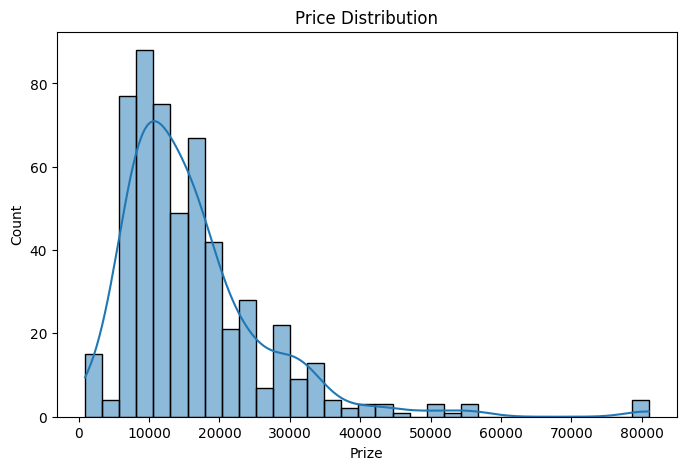

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['Prize'],kde=True)
plt.title('Price Distribution')
plt.show()

**The histogram shows that most mobile phones fall in the price range of 8,000 to 20,000. Only a small number of devices have very high prices above 30,000, indicating a right-skewed price distribution.**

In [19]:
print("The right-skewed histogram will have a long tail on the right-hand side")

The right-skewed histogram will have a long tail on the right-hand side


**Mobile Height Distribution Histplot Graph With kde**

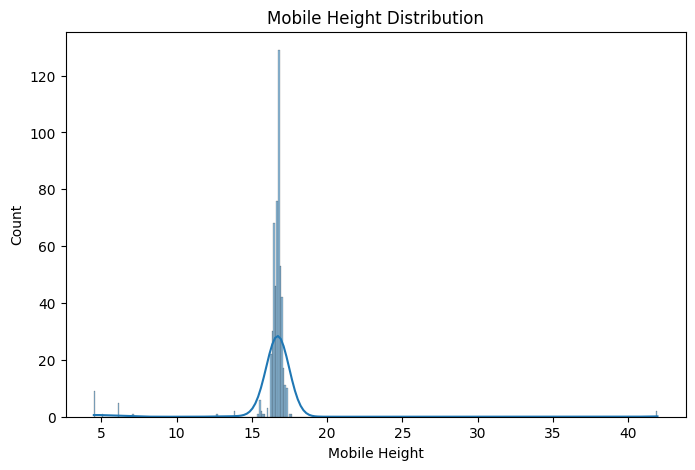

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['Mobile Height'],kde=True)
plt.title('Mobile Height Distribution')
plt.show()


**The histogram shows that most mobile devices have a height between 15 cm and 17 cm, with around 16 cm being the most common value. A few extreme values are present, which may represent outliers or data entry errors.**

**RAM Distribution Histplot Graph With kde**

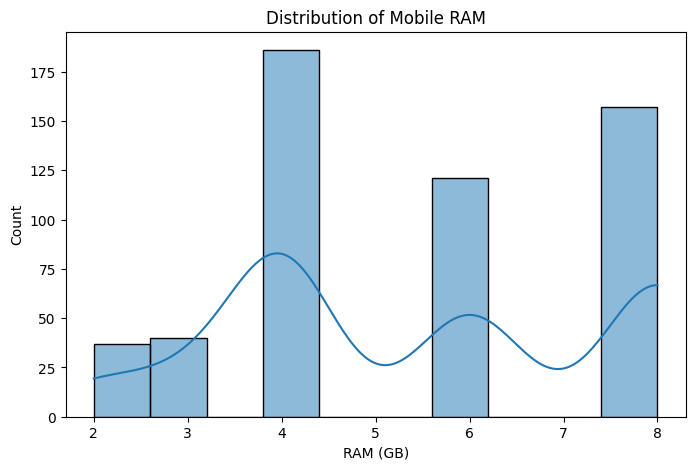

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(
    df['RAM'],
    bins=10,
    kde=True
)
plt.title("Distribution of Mobile RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Count")
plt.show()

**The histogram shows that most mobile devices have RAM between 4GB and 8GB, with 4GB being the most common configuration. Lower RAM values such as 2GB and 3GB are less frequent**

**RAM Boxplot Graph**

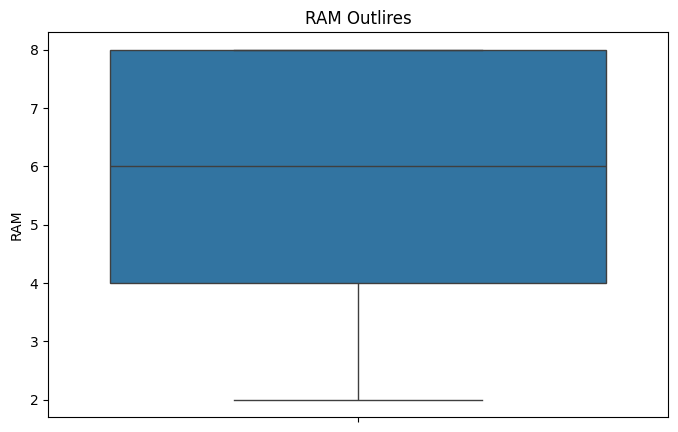

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(df['RAM'])
plt.title('RAM Outlires')
plt.show()

**The box plot shows that most mobile devices have RAM between 4GB and 8GB, with a median value of 6GB. No significant outliers are observed in the RAM distribution.**

**RAM VS Price Scatterplot**

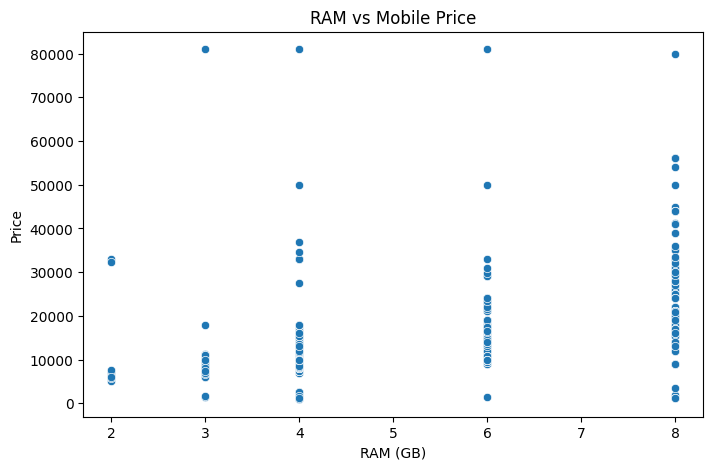

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='RAM',
    y='Prize',
    data=df
)

plt.title("RAM vs Mobile Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price")

plt.show()

**Scatter plot shows a positive relationship between** **RAM and mobile price. Devices with higher RAM tend** **to have higher prices, indicating RAM is an** **important factor in price prediction.**

**Battery VS Price Scatterplot Graph**

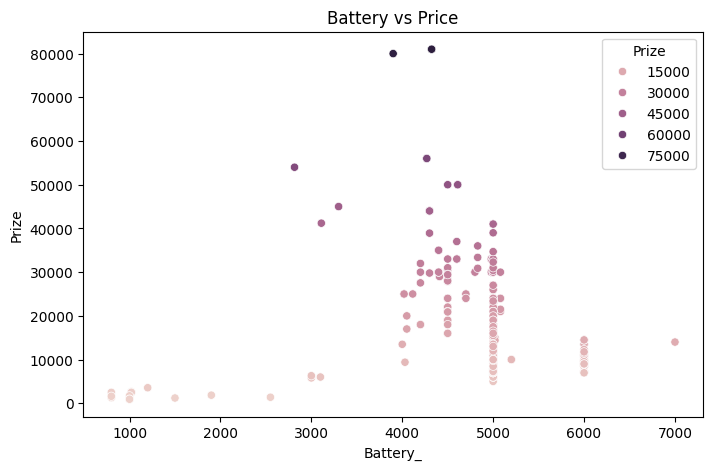

In [36]:
# from matplotlib import colors
# plt.figure(figsize=(8,5))
# sns.scatterplot(x='Battery_', y='Prize', data=df,color='orange')
# plt.title("Battery vs Price")
# plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='Battery_', y='Prize', hue='Prize', data=df)
plt.title("Battery vs Price")
plt.show()

**The scatter plot shows the relationship between battery capacity and mobile phone price. Most smartphones have battery capacity between 4000–5000 mAh, indicating that this is the most common range in the market. However, the graph shows no strong correlation between battery capacity and price, as phones with similar battery sizes have very different prices. This suggests that other factors such as processor, brand, RAM, and camera play a more significant role in determining the price of a smartphone.**

**Check The Outlier Help of Boxplot Graph**

<Axes: ylabel='Prize'>

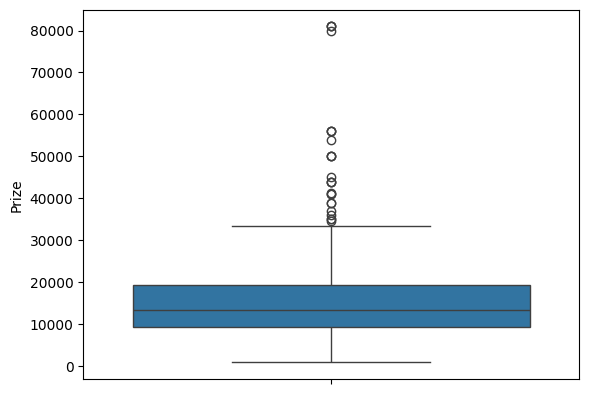

In [37]:
sns.boxplot(df['Prize'])

**The box plot shows the distribution of mobile phone prices in the dataset. Most smartphone prices lie between 9000 and 20000, with a median price around 13000. Several outliers are visible above the upper range, indicating the presence of premium smartphones with significantly higher prices. This suggests that the majority of phones fall in the mid-range price category.**

# **Data Cleaning**

**Columns Rename**

In [38]:
df.rename(columns={
    'Prize' : 'Price',
    'Battery_' : 'Battery',
    'Processor_' : 'Processor'
}, inplace=True)

**Check the rename Columns**

In [39]:
df.head(1)

,Unnamed: 0,Model,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Price
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299


**Drop the Unnecessary Column remove just like - Unnamed: 0**

In [40]:
df.drop('Unnamed: 0',axis=1, inplace=True)

**Check the again column after the Droping**

In [41]:
df.head(1)

,Model,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Price
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299


**DataType Fix**

**Fix the Columns dataType in Intger**

In [42]:
df['Price'] = df['Price'].astype(int)

# **Feature Engineering**

**Create Brand_Name & Model_Series  and Delete Model**

In [43]:
df['Brand_Name'] = df['Model'].astype(str).str.split().str[0]
df['Model_Series'] = df['Model'].astype(str).str.split(n=1).str[1]
df.drop('Model', axis=1, inplace=True)

**Check Again Columns Name**

In [44]:
df.head(1)

,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Price,Brand_Name,Model_Series
0,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299,Infinix,SMART 7


**Arrange Brand_Name and Moddel_Series columns**

In [45]:
col = df.pop('Brand_Name')      # pop the Brand_Name Colum store in Col Variable
df.insert(0,'Brand_Name',col)   # Insert the Brand_Name at 0 index

col1 = df.pop('Model_Series')     # pop the Brand_Series Colum store in Col Variable
df.insert(1,'Model_Series',col1)  # Insert the Brand_Series at 1 index


**Check The Columns After Re-arrange**

In [47]:
df.head()

,Brand_Name,Model_Series,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Price
0,Infinix,SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,Infinix,SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,MOTOROLA,G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,POCO,C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,Infinix,HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999


**Check the NullValues**

In [48]:
df.isna().sum().sort_values(ascending=False)

,0
Model_Series,4
Brand_Name,0
Colour,0
Memory,0
RAM,0
Battery,0
Rear Camera,0
Front Camera,0
AI Lens,0
Mobile Height,0


**Model_Series in present In 4 Nan Values**

In [49]:
df[df['Model_Series'].isnull()]

,Brand_Name,Model_Series,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Price
116,micromax,NaN,OMG Black,128,4,1000,0MP,0MP,0,4.5,SC6531E,1422
181,micromax,NaN,Light Silver,32,3,2550,0MP,0MP,0,4.5,SC6531E,1375
182,micromax1,NaN,Light Silver,32,3,800,0MP,0MP,0,4.5,SC6531E,1599
250,micromax,NaN,Lake Blue,64,4,1500,0MP,0MP,0,6.1,Mediatek MT6261D,1199


**Fill the Nan value in column in model_Series NaN = Unknown**

In [50]:
df[df['Model_Series'].isnull()]

,Brand_Name,Model_Series,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Price
116,micromax,NaN,OMG Black,128,4,1000,0MP,0MP,0,4.5,SC6531E,1422
181,micromax,NaN,Light Silver,32,3,2550,0MP,0MP,0,4.5,SC6531E,1375
182,micromax1,NaN,Light Silver,32,3,800,0MP,0MP,0,4.5,SC6531E,1599
250,micromax,NaN,Lake Blue,64,4,1500,0MP,0MP,0,6.1,Mediatek MT6261D,1199


**Fill the Nan value in column in model_Series NaN = Unknown**

In [51]:
df.fillna('UnKnown',inplace=True)

**i am again Checked in Nan Value form Data in Model_Series Column**

In [52]:
df[df['Model_Series'].isnull()]

,Brand_Name,Model_Series,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Price


In [53]:
df

,Brand_Name,Model_Series,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Price
0,Infinix,SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,Infinix,SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,MOTOROLA,G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,POCO,C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,Infinix,HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999
5,Infinix,HOT 30i,Glacier Blue,128,8,5000,50MP,5MP,1,16.76,G37,8999
6,Infinix,HOT 30i,Mirror Black,128,8,5000,50MP,5MP,1,16.76,G37,8999
7,Infinix,HOT 30i,Diamond White,128,8,5000,50MP,5MP,1,16.76,G37,8999
8,Infinix,HOT 30i,Diamond White,64,4,5000,50MP,5MP,1,16.76,G37,7999
9,Infinix,HOT 30i,Mirror Black,64,4,5000,50MP,5MP,1,16.76,G37,7999


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Brand_Name     541 non-null    object 
 1   Model_Series   541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery        541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor      541 non-null    object 
 11  Price          541 non-null    int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 50.8+ KB


**String Values are Clean**

In [55]:
df['Brand_Name'] = df['Brand_Name'].str.strip()

In [56]:
df['Model_Series']= df['Model_Series'].str.strip()

**Data Consistency Fix**

In [57]:
df['Brand_Name'] = df['Brand_Name'].str.upper() # brand_Name in conver to UpperCase

In [58]:
df

,Brand_Name,Model_Series,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Price
0,INFINIX,SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,INFINIX,SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,MOTOROLA,G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,POCO,C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,INFINIX,HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999
5,INFINIX,HOT 30i,Glacier Blue,128,8,5000,50MP,5MP,1,16.76,G37,8999
6,INFINIX,HOT 30i,Mirror Black,128,8,5000,50MP,5MP,1,16.76,G37,8999
7,INFINIX,HOT 30i,Diamond White,128,8,5000,50MP,5MP,1,16.76,G37,8999
8,INFINIX,HOT 30i,Diamond White,64,4,5000,50MP,5MP,1,16.76,G37,7999
9,INFINIX,HOT 30i,Mirror Black,64,4,5000,50MP,5MP,1,16.76,G37,7999


In [59]:
df.head(5)

,Brand_Name,Model_Series,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Price
0,INFINIX,SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,INFINIX,SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,MOTOROLA,G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,POCO,C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,INFINIX,HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999


# **EDA Graph**

In [60]:
print(df['Brand_Name'].unique())
print(df['Brand_Name'].value_counts())

['INFINIX' 'MOTOROLA' 'POCO' 'REDMI' 'SAMSUNG' 'VIVO' 'REALME' 'MICROMAX'
 'GOOGLE' 'MICROMAX1' 'OPPO' 'TECNO' 'NOTHING' 'I' 'ITEL' 'ONEPLUS' 'IQOO'
 'NOKIA' 'APPLE' 'LAVA']
Brand_Name
REALME       98
REDMI        75
INFINIX      65
VIVO         62
POCO         60
SAMSUNG      55
MOTOROLA     46
TECNO        17
OPPO         16
MICROMAX     13
GOOGLE        9
ONEPLUS       5
APPLE         5
NOKIA         3
ITEL          3
NOTHING       2
IQOO          2
I             2
LAVA          2
MICROMAX1     1
Name: count, dtype: int64


**Bar Graph**

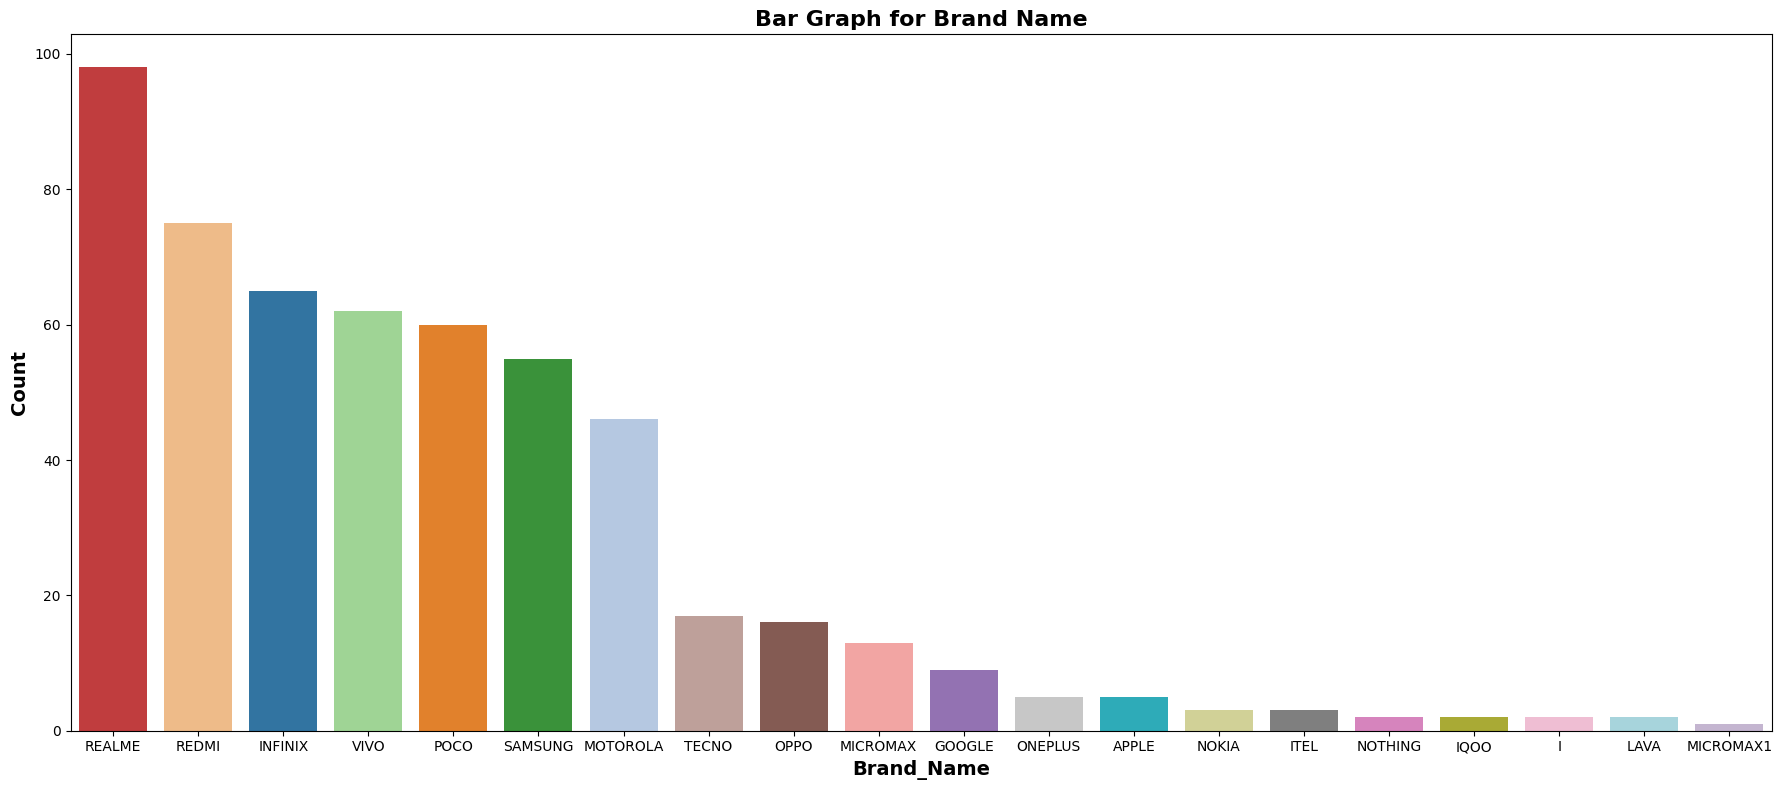

In [61]:
plt.figure(figsize=(18,8))
sns.countplot(data=df,x='Brand_Name',hue='Brand_Name',order=df['Brand_Name'].value_counts().index,palette='tab20',legend=False)
plt.title(f"Bar Graph for Brand Name",fontdict={'fontsize':16,'fontweight':'bold'})
plt.xlabel(f"Brand_Name",fontdict={'fontsize':14,'fontweight':'bold'})
plt.ylabel("Count",fontdict={'fontsize':14,'fontweight':'bold'})
plt.tight_layout()
plt.show()

**The bar graph shows the distribution of smartphone brands in the dataset. Realme has the highest number of phones, followed by Redmi, Infinix, and Vivo. These brands dominate the dataset, indicating a strong presence in the mid-range smartphone market. Premium brands such as Apple, OnePlus, and Google appear less frequently, suggesting fewer models in the dataset.**

**Chechking Which unit of Memorey More dominated in the Give DataSet**

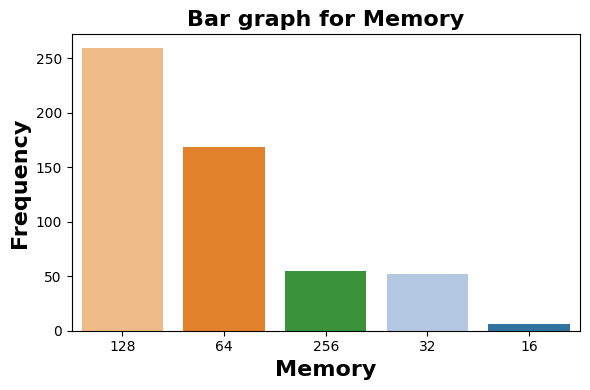

In [62]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Memory',hue='Memory',order=df['Memory'].value_counts().index,palette='tab20',legend=False)
plt.title("Bar graph for Memory",fontdict={'fontsize':16,'fontweight':'bold'})
plt.xlabel("Memory",fontdict={'fontsize':16,'fontweight':'bold'})
plt.ylabel("Frequency",fontdict={'fontsize':16,'fontweight':'bold'})
plt.tight_layout()
plt.show()

**The bar graph shows the distribution of smartphone storage in the dataset. 128 GB storage is the most common, followed by 64 GB. Higher storage options like 256 GB appear less frequently, while 32 GB and 16 GB are rare. This indicates that most modern smartphones in the dataset come with 128 GB storage, reflecting current market trends.**

**Show The Graph RAM PIE Chart**

In [63]:
values = df['RAM'].value_counts()   # count of each RAM unit
length = len(df['RAM'])             # total no. of rows.
percentage = round((values/length) * 100,2)   # calculating the percentage of RAM unit.
percentage

,count
RAM,
4,34.38
8,29.02
6,22.37
3,7.39
2,6.84


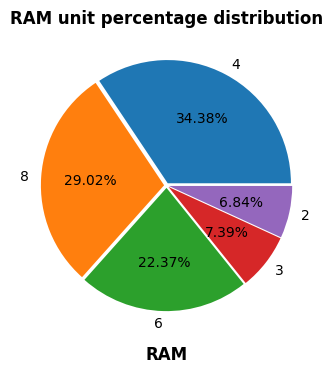

In [64]:
plt.figure(figsize=(6,4))
percentage.plot(kind='pie',autopct = '%1.2f%%',explode = [0.02]*len(values))
plt.title('RAM unit percentage distribution',fontdict={'fontsize':12,'fontweight':'bold'})
plt.xlabel('RAM',fontdict={'fontsize':12,'fontweight':'bold'})
plt.ylabel("")
plt.show()


**The pie chart shows the percentage distribution of RAM units in the dataset. 4 GB RAM has the highest share, followed by 8 GB and 6 GB RAM. Lower RAM options like 3 GB and 2 GB appear less frequently, indicating that most smartphones in the dataset use 4 GB or higher RAM configurations.**

**Battery Checking normality of the column by plotting histogram. By plotting histogram and kde plot**

**HIstogram_plot Graph**

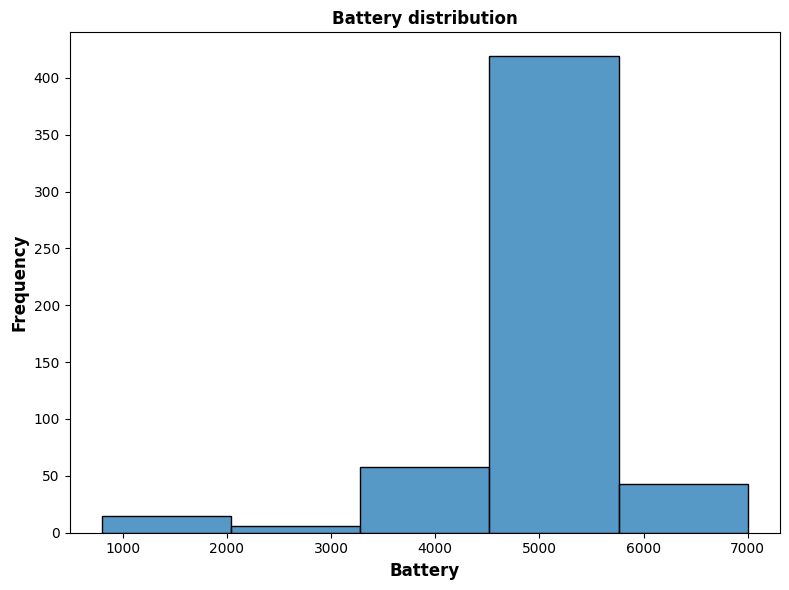

In [65]:
plt.figure(figsize=(8,6))
sns.histplot(data=df,x='Battery',bins=5)
plt.title('Battery distribution',fontdict={'fontsize':12,'fontweight':'bold'})
plt.xlabel('Battery',fontdict={'fontsize':12,'fontweight':'bold'})
plt.ylabel("Frequency",fontdict={'fontsize':12,'fontweight':'bold'})
plt.tight_layout()
plt.show()

**The histogram shows the distribution of smartphone battery capacities in the dataset. Most smartphones have battery capacity between 4500 mAh and 5500 mAh, indicating that 5000 mAh is the most common battery size. Phones with very low or very high battery capacities appear less frequently.**

**KDE_Plot**

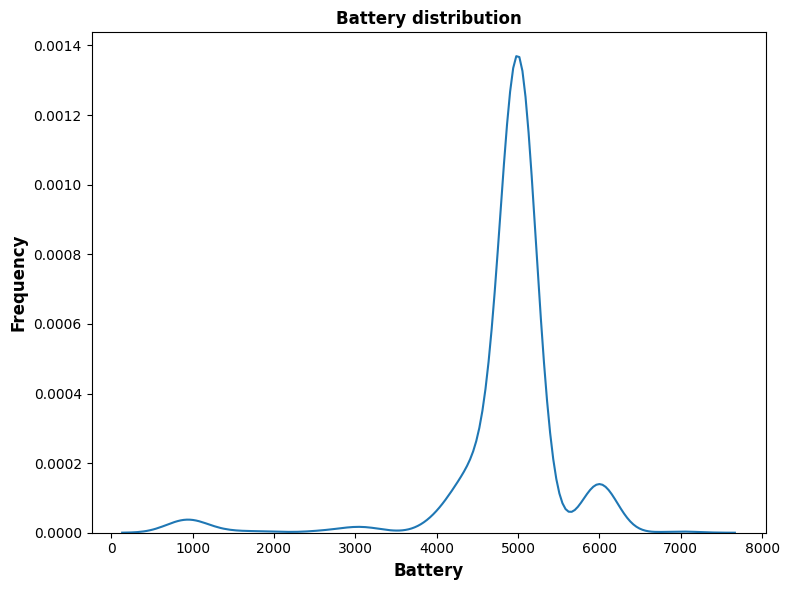

In [66]:
plt.figure(figsize=(8,6))
sns.kdeplot(data=df,x='Battery')
plt.title('Battery distribution',fontdict={'fontsize':12,'fontweight':'bold'})
plt.xlabel('Battery',fontdict={'fontsize':12,'fontweight':'bold'})
plt.ylabel("Frequency",fontdict={'fontsize':12,'fontweight':'bold'})
plt.tight_layout()
plt.show()

**The KDE plot shows the density distribution of smartphone battery capacities. The highest peak appears around 5000 mAh, indicating that most smartphones in the dataset have battery capacity near this value. Phones with very low or very high battery capacities occur less frequently.**

In [67]:
print("Most phones have a battery capacity around 5000 mAh.\nSome phones are around 6000 mAh, and very few phones have low battery capacity.\nThis means the data is clustered and not normally distributed, with slight left skewness.")

Most phones have a battery capacity around 5000 mAh.
Some phones are around 6000 mAh, and very few phones have low battery capacity.
This means the data is clustered and not normally distributed, with slight left skewness.


In [68]:
skew = df['Battery'].skew()   ## checking the skewness
skew                            ## since it is -ve skewed, applying capping transformation

np.float64(-3.3042495558784655)

**Checking which rear_Camera unit is dominated in given Data set**

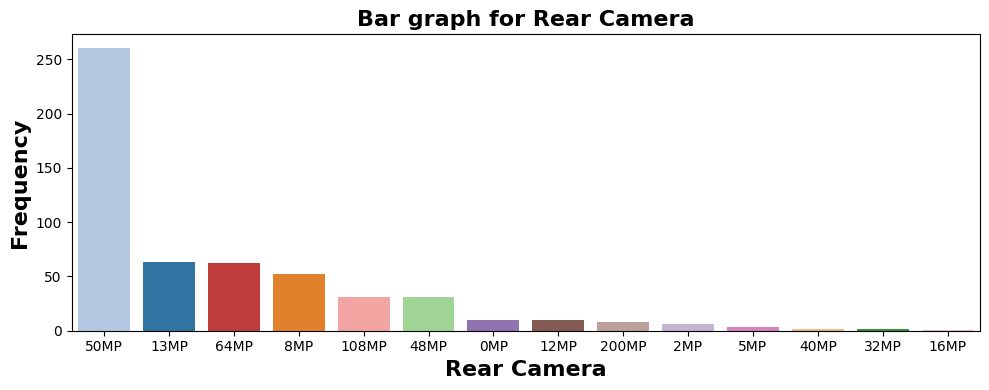

In [69]:
plt.figure(figsize=(10,4))
sns.countplot(data=df,x='Rear Camera',hue='Rear Camera',order=df['Rear Camera'].value_counts().index,palette='tab20',legend=False)
plt.title("Bar graph for Rear Camera",fontdict={'fontsize':16,'fontweight':'bold'})
plt.xlabel("Rear Camera",fontdict={'fontsize':16,'fontweight':'bold'})
plt.ylabel("Frequency",fontdict={'fontsize':16,'fontweight':'bold'})
plt.tight_layout()
plt.show()

**The bar graph shows the distribution of rear camera resolutions in the dataset. 50MP cameras are the most common, followed by 13MP and 64MP cameras. Higher-resolution cameras such as 108MP and 200MP appear less frequently, indicating that most smartphones in the dataset use mid-range camera resolutions.**

In [70]:
print("The dataset is heavily dominated by 50 MP rear cameras, followed by 13 MP and 64 MP. Other camera resolutions have much lower representation,\nindicating strong market standardization around 50 MP sensors.")

The dataset is heavily dominated by 50 MP rear cameras, followed by 13 MP and 64 MP. Other camera resolutions have much lower representation,
indicating strong market standardization around 50 MP sensors.


**Cheking which Front_Camera unit is dominated in given dataSet**

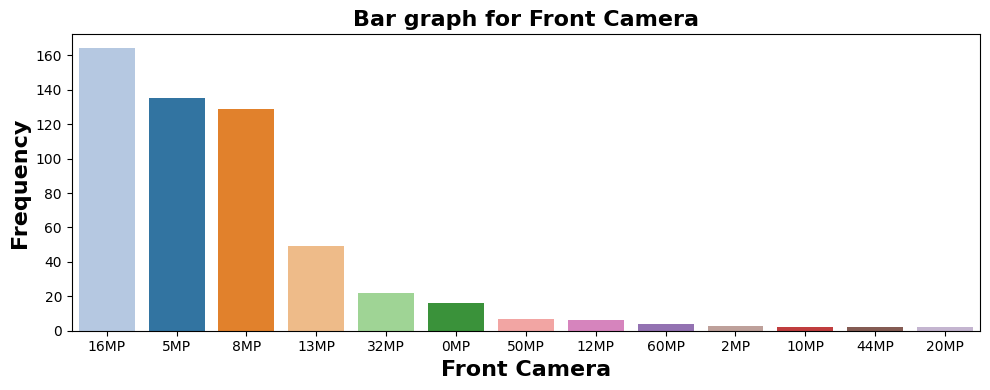

In [71]:
plt.figure(figsize=(10,4))
sns.countplot(data=df,x='Front Camera',hue='Front Camera',order=df['Front Camera'].value_counts().index,palette='tab20',legend=False)
plt.title("Bar graph for Front Camera",fontdict={'fontsize':16,'fontweight':'bold'})
plt.xlabel("Front Camera",fontdict={'fontsize':16,'fontweight':'bold'})
plt.ylabel("Frequency",fontdict={'fontsize':16,'fontweight':'bold'})
plt.tight_layout()
plt.show()

**The bar graph shows the distribution of front camera resolutions in the dataset. 16MP front cameras are the most common, followed by 5MP and 8MP cameras. Higher resolution selfie cameras such as 32MP and 50MP appear less frequently, indicating that most smartphones use mid-range front camera resolutions.**

In [72]:
print("The dataset is dominated by 16 MP front cameras, followed by 5 MP and 8 MP. Higher resolutions such as 32 MP and 50 MP appear less frequently. \nSeveral other front camera categories occur very rarely, indicating an imbalanced distribution across front camera resolutions.")

The dataset is dominated by 16 MP front cameras, followed by 5 MP and 8 MP. Higher resolutions such as 32 MP and 50 MP appear less frequently. 
Several other front camera categories occur very rarely, indicating an imbalanced distribution across front camera resolutions.


**AI Lens - 1 represent AI lens is available in phone and 0 represent is unavailable**

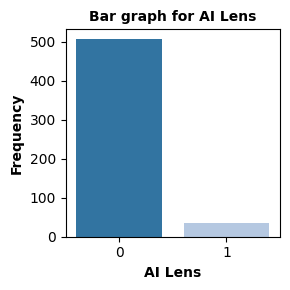

In [73]:
plt.figure(figsize=(3,3))
sns.countplot(data=df,x='AI Lens',hue='AI Lens',order=df['AI Lens'].value_counts().index,palette='tab20',legend=False)
plt.title("Bar graph for AI Lens",fontdict={'fontsize':10,'fontweight':'bold'})
plt.xlabel("AI Lens",fontdict={'fontsize':10,'fontweight':'bold'})
plt.ylabel("Frequency",fontdict={'fontsize':10,'fontweight':'bold'})
plt.tight_layout()
plt.show()

**The bar graph shows the distribution of AI Lens features in the dataset. Most smartphones have a value of 0, indicating that AI Lens is not present in the majority of devices, while only a small number of phones include the AI Lens feature.**

In [74]:
print("The AI Lens variable is highly imbalanced, with most values being 0 (No AI Lens) and only a few 1 (AI Lens present).")

The AI Lens variable is highly imbalanced, with most values being 0 (No AI Lens) and only a few 1 (AI Lens present).


**Mobile Height - Checking distribution of Mobile Height. By plotting histograms and kde plots**

**Histogram Graph**

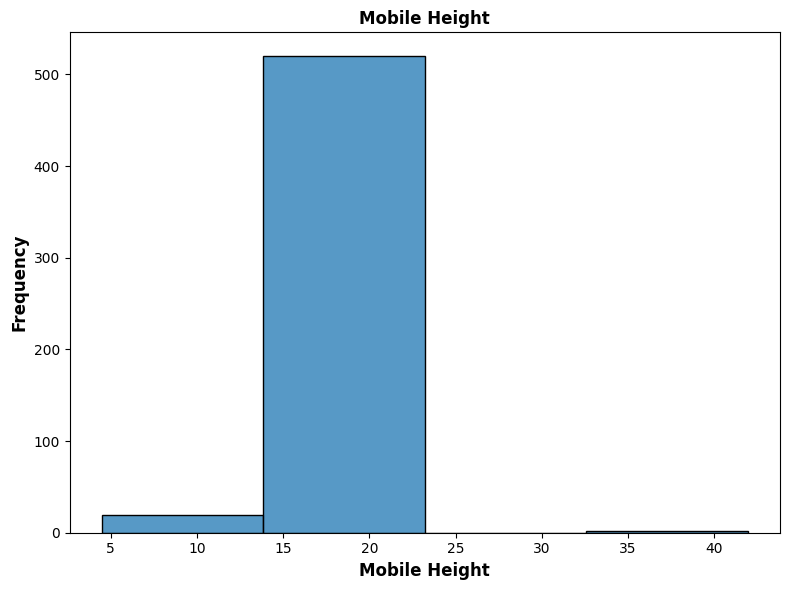

In [75]:
plt.figure(figsize=(8,6))
sns.histplot(data=df,x='Mobile Height',bins=4)
plt.title('Mobile Height',fontdict={'fontsize':12,'fontweight':'bold'})
plt.xlabel('Mobile Height',fontdict={'fontsize':12,'fontweight':'bold'})
plt.ylabel("Frequency",fontdict={'fontsize':12,'fontweight':'bold'})
plt.tight_layout()
plt.show()

**The histogram shows the distribution of mobile phone heights in the dataset. Most smartphones fall within the 15–22 height range, indicating that medium-sized phones are the most common. Very small or very large phones appear less frequently in the dataset.**

**KDE_Plot Graph**

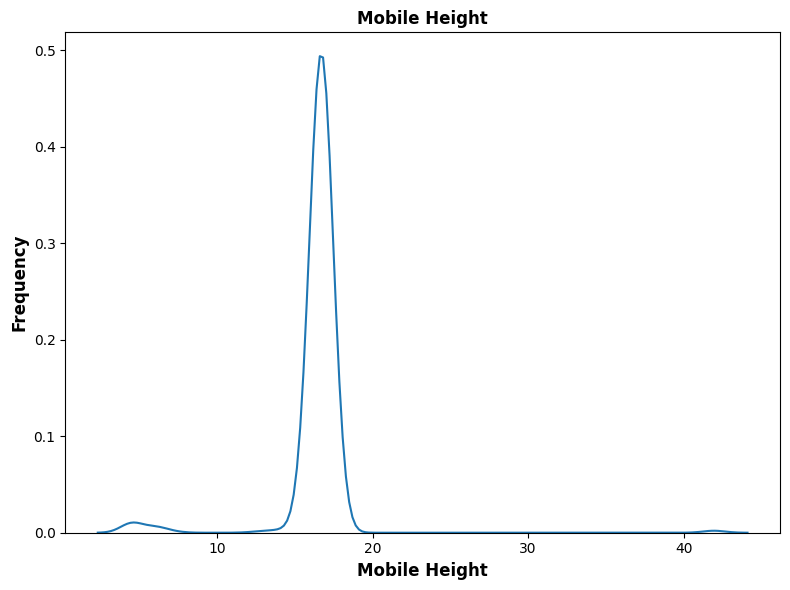

In [76]:
plt.figure(figsize=(8,6))
sns.kdeplot(data=df,x='Mobile Height')
plt.title('Mobile Height',fontdict={'fontsize':12,'fontweight':'bold'})
plt.xlabel('Mobile Height',fontdict={'fontsize':12,'fontweight':'bold'})
plt.ylabel("Frequency",fontdict={'fontsize':12,'fontweight':'bold'})
plt.tight_layout()
plt.show()

**The KDE plot shows the density distribution of mobile phone heights. The highest peak appears around 17–18 units, indicating that most smartphones in the dataset fall within this height range. Very small or very large phone heights appear less frequently.**

In [77]:
print("Most mobile heights are around 16.7, and the IQR (16.51–16.94) is very small, showing that most phones have similar height.\nHowever, the minimum (4.5) and maximum (41.94) values are extreme, which may indicate outliers or data-entry/unit errors that should be checked before modeling.")

Most mobile heights are around 16.7, and the IQR (16.51–16.94) is very small, showing that most phones have similar height.
However, the minimum (4.5) and maximum (41.94) values are extreme, which may indicate outliers or data-entry/unit errors that should be checked before modeling.


# **Brand VS Price Graph**

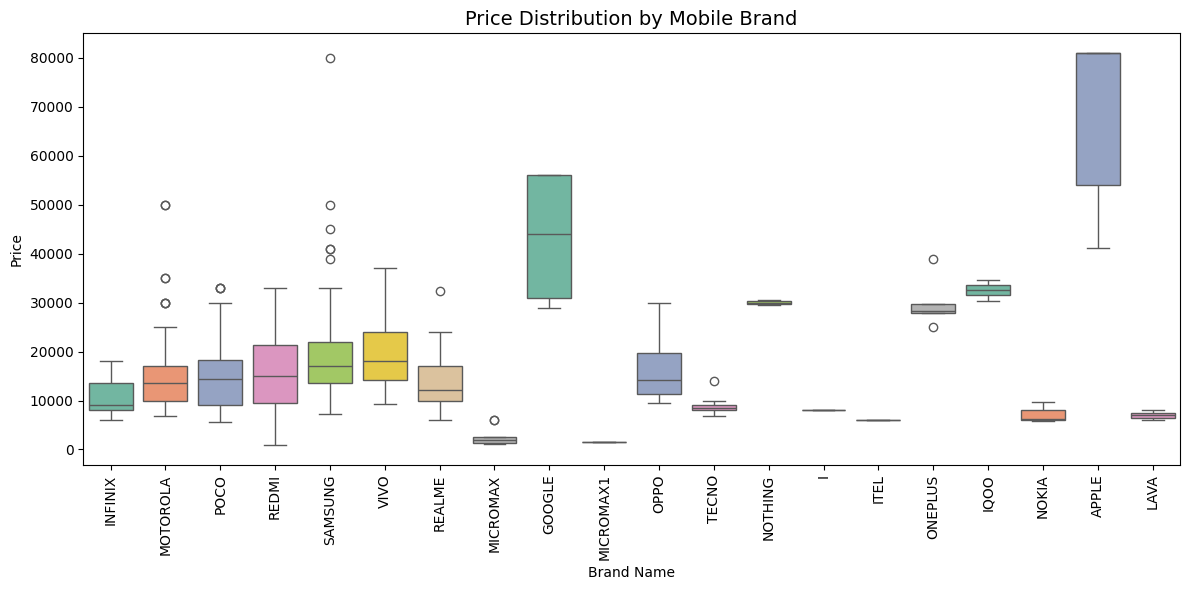

In [82]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="Brand_Name",
    y="Price",
    hue="Brand_Name",
    data=df,
    palette="Set2",
    legend=False
)

plt.title("Price Distribution by Mobile Brand", fontsize=14)
plt.xlabel("Brand Name")
plt.ylabel("Price")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

**The box plot compares the price distribution across different smartphone brands. Some brands show higher price ranges, indicating premium devices, while others have lower median prices representing budget or mid-range phones. The presence of outliers suggests that a few models are significantly more expensive than the typical price range.**

**Processor - Checking which processor dominant in given dataset**

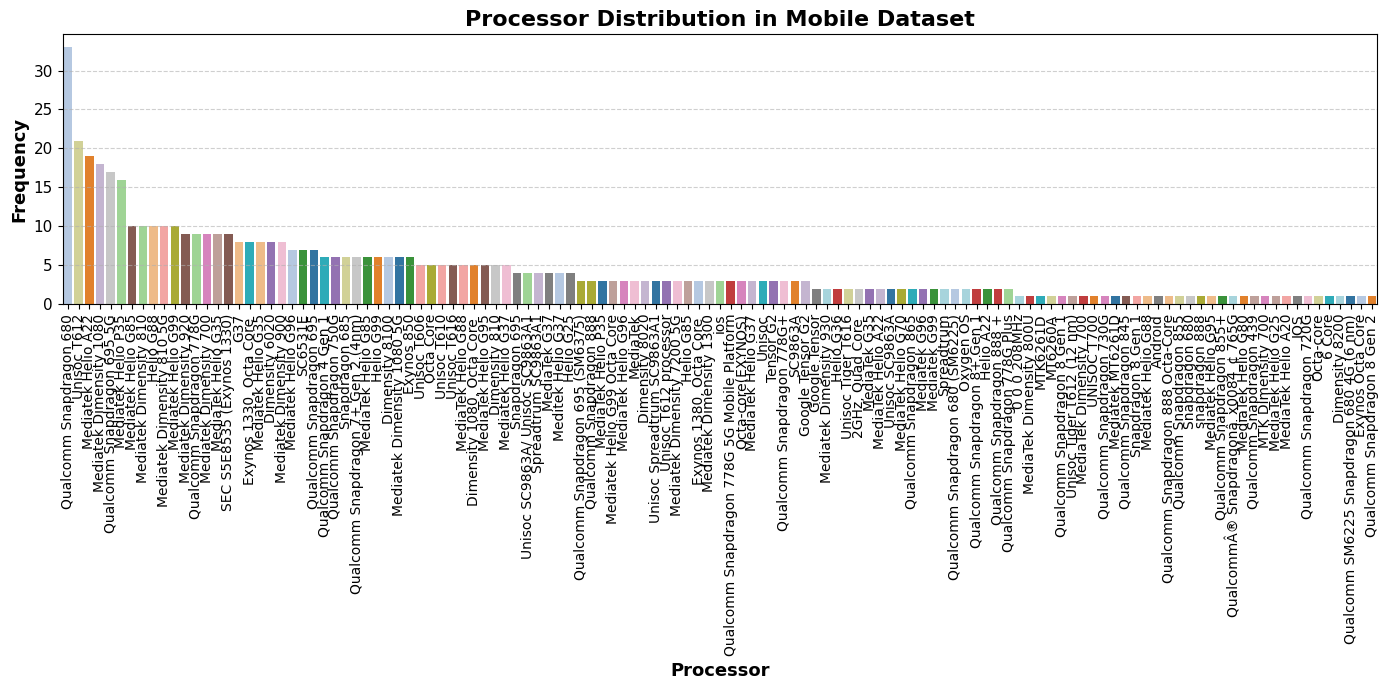

In [84]:
plt.figure(figsize=(14,7))

sns.countplot(
    data=df,
    x='Processor',
    hue='Processor',
    order=df['Processor'].value_counts().index,
    palette='tab20',
    legend=False
)

plt.title("Processor Distribution in Mobile Dataset", fontsize=16, fontweight='bold')
plt.xlabel("Processor", fontsize=13, fontweight='bold')
plt.ylabel("Frequency", fontsize=13, fontweight='bold')

plt.xticks(rotation=90, fontsize=10)  # processor names visible
plt.yticks(fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.6)  # professional grid

plt.tight_layout()
plt.show()

**The bar graph shows the distribution of processors used in the smartphones dataset. Certain processors, particularly from Qualcomm Snapdragon and MediaTek series, appear more frequently, indicating their popularity in many devices. Many other processors appear only a few times, suggesting they are used in limited smartphone models.**

# **Label Encoding**

**Trainer instruction ke according categorical features**
**ko numeric form me convert karne ke liye Label Encoding**
**use kiya gaya.**

**Categorical Columns Identify**

In [85]:
df.select_dtypes(include=['object']).columns

Index(['Brand_Name', 'Model_Series', 'Colour', 'Rear Camera', 'Front Camera',
       'Processor'],
      dtype='object')

**Label Encoding Apply**

In [86]:
le = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

**Check the Label Encoding**

In [87]:
df.head()

,Brand_Name,Model_Series,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Price
0,3,119,159,64,4,6000,3,10,1,16.76,113,7299
1,3,119,20,64,4,6000,3,10,1,16.76,113,7299
2,9,49,149,128,8,5000,10,4,0,16.64,75,11999
3,14,37,201,32,2,5000,13,10,0,16.56,56,5649
4,3,73,130,128,8,5000,10,10,1,16.76,14,8999


**Feature vs Price Graph**

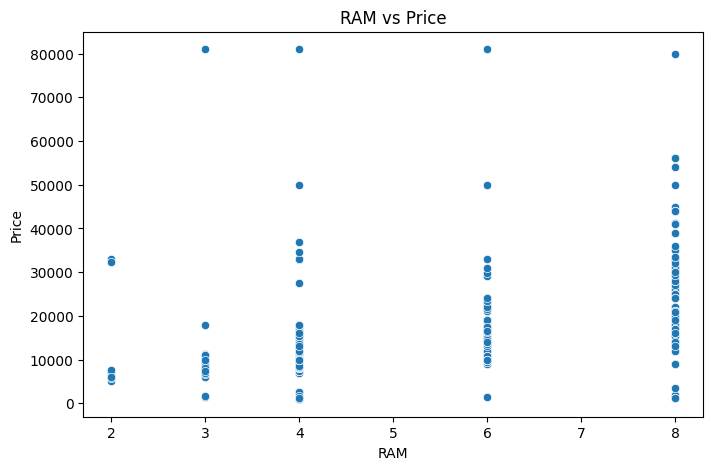

In [88]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["RAM"], y=df["Price"])
plt.title("RAM vs Price")
plt.show()

**The scatter plot shows the relationship between RAM and smartphone price. Phones with lower RAM (2GB–3GB) mostly fall in the lower price range, while devices with higher RAM such as 6GB and 8GB tend to have higher prices. This suggests that RAM capacity has a positive influence on smartphone price.**

In [89]:
print("Ram Increase then Price Increase")

Ram Increase then Price Increase


**Final Clean DataSet**

In [90]:
df.to_csv("clean_mobile_dataset.csv", index=False)

In [91]:
df.head()

,Brand_Name,Model_Series,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Price
0,3,119,159,64,4,6000,3,10,1,16.76,113,7299
1,3,119,20,64,4,6000,3,10,1,16.76,113,7299
2,9,49,149,128,8,5000,10,4,0,16.64,75,11999
3,14,37,201,32,2,5000,13,10,0,16.56,56,5649
4,3,73,130,128,8,5000,10,10,1,16.76,14,8999


# **Handle The Outliers with IQR Method**

In [92]:
outlier_columns = ["Price", "Mobile Height"]

def remove_outliers_iqr(data, columns):
    df_clean = data.copy()

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        print(f"\nProcessing: {col}")
        print("Lower Bound:", lower_bound)
        print("Upper Bound:", upper_bound)

        before_rows = df_clean.shape[0]

        df_clean = df_clean[
            (df_clean[col] >= lower_bound) &
            (df_clean[col] <= upper_bound)
        ]

        after_rows = df_clean.shape[0]

        print("Rows Removed:", before_rows - after_rows)

    return df_clean

df_cleaned = remove_outliers_iqr(df, outlier_columns)

print("\nFinal Shape After Outlier Removal:", df_cleaned.shape)


Processing: Price
Lower Bound: -5695.0
Upper Bound: 34265.0
Rows Removed: 25

Processing: Mobile Height
Lower Bound: 16.011250000000004
Upper Bound: 17.341250000000002
Rows Removed: 28

Final Shape After Outlier Removal: (488, 12)


# **Why We NOT Remove Outliers From Other Columns**

**AI Lens = Binary feature (0/1)**

**IQR method not suitable for categorical/binary data.**

**Memory = Higher storage phones (256GB, 512GB) are valid premium models, not statistical errors.**

**Battery = Most values clustered around 5000mAh, IQR becomes zero falsely flags normal values.**

**RAM = Small discrete range (4GB–12GB), natural product variation**

# **Correlation Heatmap With EDA Graph**

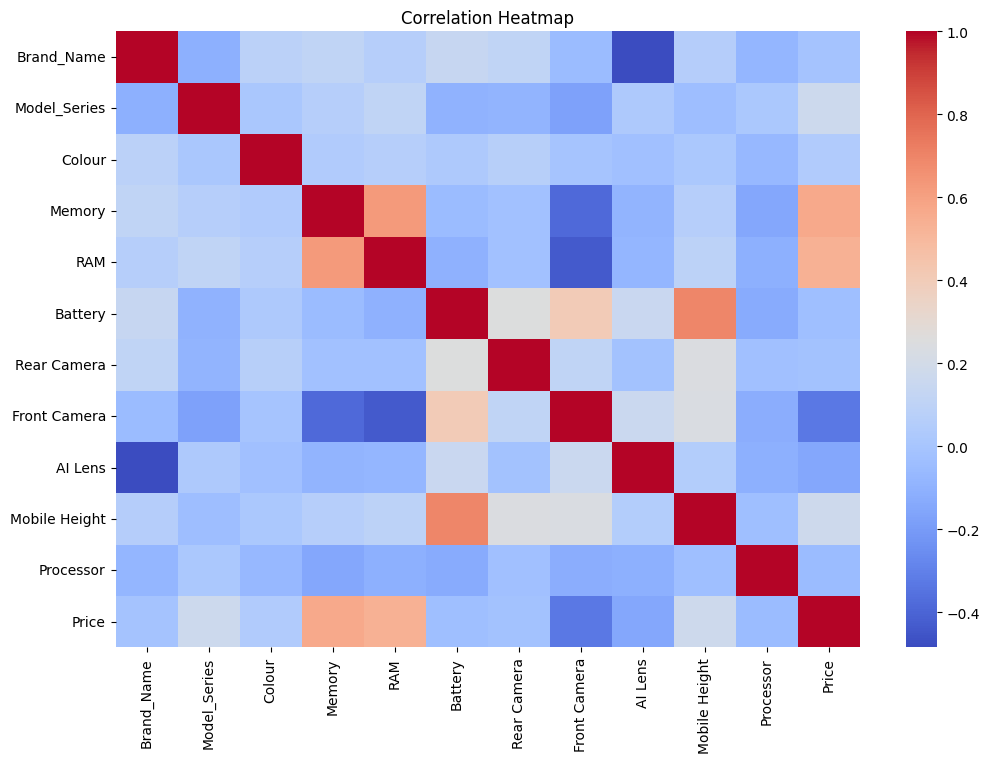

In [93]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**The correlation heatmap shows the relationships between different smartphone features. RAM and Memory have a positive correlation with Price, indicating that phones with higher RAM and storage generally have higher prices. Most other features show weak or moderate correlations, suggesting that multiple factors influence smartphone pricing.**

# **Top Ten Feature Jo Price ke sath Jada Correlated hai**

Price            1.000000
Memory           0.566660
RAM              0.532024
Front Camera     0.333833
Mobile Height    0.176009
Model_Series     0.164923
AI Lens          0.153691
Processor        0.050244
Colour           0.038895
Battery          0.034297
Name: Price, dtype: float64


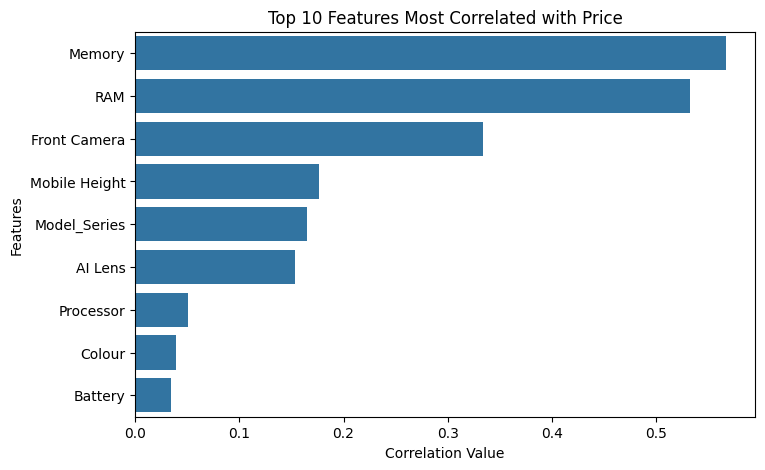

In [94]:
correlation = df.corr(numeric_only=True)

price_corr = correlation["Price"]

top10 = price_corr.abs().sort_values(ascending=False).head(10)

print(top10)

top10 = top10.drop("Price")

plt.figure(figsize=(8,5))
sns.barplot(x=top10.values, y=top10.index)

plt.title("Top 10 Features Most Correlated with Price")
plt.xlabel("Correlation Value")
plt.ylabel("Features")

plt.show()

**The bar chart shows the top features most correlated with smartphone price. Memory and RAM have the highest correlation with price, indicating that phones with higher storage and RAM tend to be more expensive. Other features such as front camera and mobile height show moderate influence, while battery and color have relatively weak correlations with price.**

**Top Correlated  Feature with Price**

In [95]:
df.corr()['Price'].sort_values(ascending=False)

,Price
Price,1.000000
Memory,0.566660
RAM,0.532024
Mobile Height,0.176009
Model_Series,0.164923
Colour,0.038895
Brand_Name,-0.010087
Rear Camera,-0.019597
Battery,-0.034297
Processor,-0.050244


# **Strong Positive Features (Price Badhta Hai)**

Memory            0.566           

RAM               0.532           

Front Camera 12MP 0.525           

Rear Camera 12MP  0.414           

# **Medium Correlation**
Processor_ios                 0.29

Brand_Name_Google             0.32

Model_Name_Galaxy S23         0.25

# **Near Zero Correlation**
Colour_Blue      0.02

Colour_White     0.05

# **Negative Correlation (Price Kam Hota Hai)**
Front Camera 5MP     -0.41

Rear Camera 8MP      -0.27

AI Lens               -0.15

Brand_Name_Infinix    -0.19

**RAM strongly positively correlated**

**Storage correlated**

**Processor type moderate effect**

**Camera medium effect**

**Battery weak to moderate**

**Strong Positive Correlation (Major Price)**

Memory (0.56) shows strong positive correlation with price

RAM (0.53) is a major pricing driver

Higher front camera resolution (16MP, 32MP) increases price

Premium processors (Dimensity 1080, Snapdragon 7+ Gen 2) positively impact pricing

**Moderate Positive Correlation**

High megapixel rear cameras moderately increase price

Advanced processors contribute to higher price positioning

Larger display height has moderate influence

**Strong Negative Correlation (Budget Indicators)**

Low megapixel cameras strongly indicate budget devices

Entry-level processors (Helio A22, SC6531E) reduce pricing

Phones with 5MP front camera fall in lower price segment

# **Model Building**

In [96]:
X = df.drop('Price', axis=1)
y = df['Price']

## **Train-Test Split**

In [97]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Model Traning**

**Linear Regression**

In [98]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

**RandomForestRegressor**

**Random Forest can handle non-linear relationships and**
**also provides feature importance which helps identify**
**important mobile specifications affecting price.**

In [99]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

**Model Evaluation**

In [100]:
print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

print("\nRandom Forest Results")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Linear Regression Results
MAE: 4528.204189606554
RMSE: 9588.930055884408
R2 Score: 0.33288071343220127

Random Forest Results
MAE: 1911.4898073394495
RMSE: 5394.739848866018
R2 Score: 0.7888436200867857


**Lower MAE & RMSE = Better**

**Higher R2 = Better**

**Random Forest usually performs better**

# **Feature Importance Analysis**

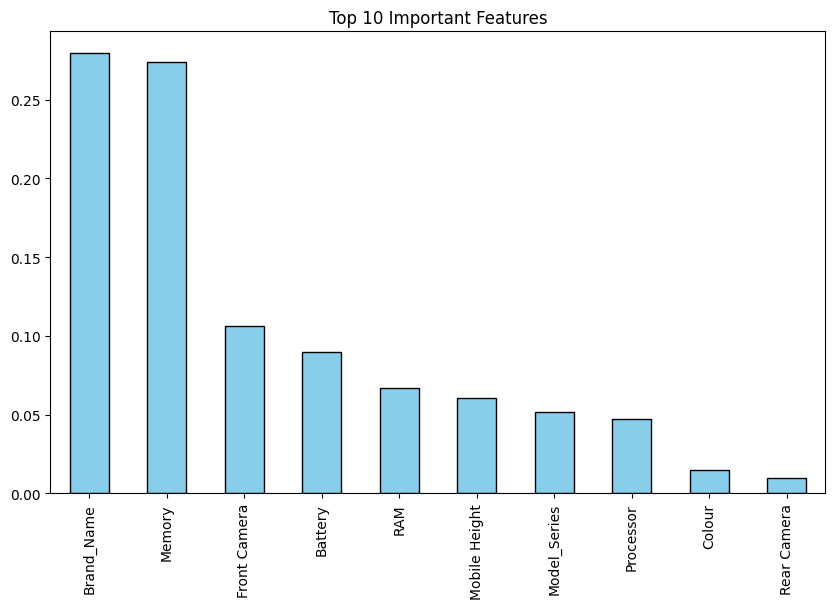

In [101]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot( kind='bar',
    color='skyblue',
    edgecolor='black')
plt.title("Top 10 Important Features")
plt.show()

**The feature importance plot from the Random Forest model shows the top features influencing smartphone price prediction. Brand Name and Memory are the most important features, followed by Front Camera and Battery. Other features such as Colour and Rear Camera have relatively lower importance, indicating they contribute less to the model's prediction**

**Yeh graph batata hai Model ke according kaunse 10 features sabse zyada price ko influence kar rahe hain**

# **Most influential features affecting price:**
**X-axis par features ke naam hain**

**Memory**

**Battery**

**RAM**

**Front Camera 12MP**

**Mobile Height**

**Brand_Name Google**

**Model_Name_iPhone 14 Plus**

**Front Camera 32MP**

**Front Camera 5MP**

**Rear Camera 12MP**

Yeh sab wo variables hain jo model ne use kiye price predict karne ke liye

# **Y-axis par numbers hai**
**Yeh importance score ha**

**Jitna bada number, utna zyada feature important**

In [102]:
df.head()

,Brand_Name,Model_Series,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Price
0,3,119,159,64,4,6000,3,10,1,16.76,113,7299
1,3,119,20,64,4,6000,3,10,1,16.76,113,7299
2,9,49,149,128,8,5000,10,4,0,16.64,75,11999
3,14,37,201,32,2,5000,13,10,0,16.56,56,5649
4,3,73,130,128,8,5000,10,10,1,16.76,14,8999


# **Business Recommendations**

**Based on the analysis, features like RAM, memory, processor, battery, and** **camera have a strong influence on mobile phone prices. Companies can use this** **model to design better products and set competitive pricing strategies. This** **approach helps organizations make data-driven business decisions in the mobile** **market.**

**Premium pricing for high Memory RAM & Battery phones**

**Focus marketing on processor & performance**

**Camera-based pricing for mid-range phones**

**Brand positioning strongly affects price**

**High RAM mobiles should be priced higher.**

**Snapdragon processors increase phone value.**

**Premium brands should maintain premium pricing.**

# **Final Conclusion in this Project Mobile Price Prediction**

**In this project, a machine learning model was developed to predict mobile phone** **prices based on their specifications. After performing data preprocessing and** **applying Label Encoding, a Random Forest Regressor model was trained to make** **predictions. Feature importance analysis showed that features like RAM, memory,** **processor, and battery significantly influence mobile phone prices. This model** **can help organizations understand key pricing factors and make better business** **decisions.**